# Supply Chain Inventory Reorder Risk Analysis

This notebook begins the supply chain inventory project by reviewing the raw dataset, checking data quality, and preparing the fields needed for inventory planning analysis.

The dataset includes inventory levels, reorder points, supplier lead times, sales volume, demand forecasts, promotion flags, and stockout flags. Before deciding on the main outcome, I first check whether the stockout field contains usable variation. If it does not, the analysis will use reorder risk as the main planning signal instead.

## 1. Import Libraries

I use pandas and NumPy for data cleaning and summary analysis. Matplotlib is used for simple exploratory charts.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load the Dataset

In [41]:
df = pd.read_csv("supply_chain_dataset1.csv")

df.head()

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70


## 3. Initial Data Review

Before changing the dataset, I review its size, structure, missing values, duplicate rows, and basic numeric summaries.

In [42]:
df.shape

(91250, 15)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91250 entries, 0 to 91249
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     91250 non-null  object 
 1   SKU_ID                   91250 non-null  object 
 2   Warehouse_ID             91250 non-null  object 
 3   Supplier_ID              91250 non-null  object 
 4   Region                   91250 non-null  object 
 5   Units_Sold               91250 non-null  int64  
 6   Inventory_Level          91250 non-null  int64  
 7   Supplier_Lead_Time_Days  91250 non-null  int64  
 8   Reorder_Point            91250 non-null  int64  
 9   Order_Quantity           91250 non-null  int64  
 10  Unit_Cost                91250 non-null  float64
 11  Unit_Price               91250 non-null  float64
 12  Promotion_Flag           91250 non-null  int64  
 13  Stockout_Flag            91250 non-null  int64  
 14  Demand_Forecast       

In [44]:
df.isna().sum()

,0
Date,0
SKU_ID,0
Warehouse_ID,0
Supplier_ID,0
Region,0
Units_Sold,0
Inventory_Level,0
Supplier_Lead_Time_Days,0
Reorder_Point,0
Order_Quantity,0


In [45]:
df.duplicated().sum()

np.int64(0)

In [46]:
df.describe()

,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
count,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.0,91250.000000
mean,20.054564,471.522312,7.984000,300.068000,19.272493,12.203320,18.261800,0.101589,0.0,20.082033
std,9.068602,133.488002,3.907929,54.879945,82.340831,4.574982,7.121136,0.302109,0.0,9.503955
min,0.000000,168.000000,2.000000,201.000000,0.000000,5.020000,6.950000,0.000000,0.0,0.000000
25%,13.000000,370.000000,4.000000,252.000000,0.000000,8.180000,12.000000,0.000000,0.0,12.950000
50%,20.000000,461.000000,8.000000,300.000000,0.000000,11.990000,18.180000,0.000000,0.0,19.950000
75%,27.000000,564.000000,11.000000,346.000000,0.000000,16.320000,23.390000,0.000000,0.0,26.930000
max,59.000000,990.000000,14.000000,398.000000,499.000000,19.760000,35.100000,1.000000,0.0,61.420000


## 4. Initial Review Notes

The dataset contains 91,250 records and 15 fields. There are no missing values and no duplicate rows, so the first cleaning step is mostly structural rather than corrective.

The main numeric fields are already stored in usable numeric formats. The date field still needs to be converted from text to datetime format.

The most important issue is analytical rather than technical: `Stockout_Flag` contains only zero values. Because the field has no variation, this project should not force a stockout prediction workflow.

## 5. Clean Column Names

The original column names are readable, but lowercase snake_case names are easier to use consistently across Python, SQL, and Tableau.

In [47]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['date', 'sku_id', 'warehouse_id', 'supplier_id', 'region', 'units_sold',
       'inventory_level', 'supplier_lead_time_days', 'reorder_point',
       'order_quantity', 'unit_cost', 'unit_price', 'promotion_flag',
       'stockout_flag', 'demand_forecast'],
      dtype='object')

## 6. Confirm Core Fields

I checked that the dataset contains the fields needed for the inventory analysis.

In [48]:
expected_columns = [
    "date",
    "sku_id",
    "warehouse_id",
    "supplier_id",
    "region",
    "units_sold",
    "inventory_level",
    "supplier_lead_time_days",
    "reorder_point",
    "order_quantity",
    "unit_cost",
    "unit_price",
    "promotion_flag",
    "stockout_flag",
    "demand_forecast"
]

missing_columns = [col for col in expected_columns if col not in df.columns]

missing_columns

[]

In [49]:
if len(missing_columns) == 0:
    print("All expected columns are present.")
else:
    print("Missing columns:")
    print(missing_columns)

All expected columns are present.


## 7. Clean Date Field

The date column is converted to datetime format so monthly patterns can be reviewed later.

In [50]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["date"].min(), df["date"].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2024-12-30 00:00:00'))

In [51]:
df["date"].isna().sum()

np.int64(0)

In [52]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["month_year"] = df["date"].dt.to_period("M").astype(str)

df[["date", "year", "month", "month_year"]].head()

,date,year,month,month_year
0,2024-01-01,2024,1,2024-01
1,2024-01-02,2024,1,2024-01
2,2024-01-03,2024,1,2024-01
3,2024-01-04,2024,1,2024-01
4,2024-01-05,2024,1,2024-01


## 8. Review Key Fields

These checks show how many SKUs, warehouses, suppliers, and regions are represented in the dataset. I also review the promotion and stockout indicators before using either field in the analysis.

In [53]:
for col in ["sku_id", "warehouse_id", "supplier_id", "region"]:
    print(f"{col}: {df[col].nunique()} unique values")

sku_id: 50 unique values
warehouse_id: 5 unique values
supplier_id: 10 unique values
region: 4 unique values


In [54]:
for col in ["promotion_flag", "stockout_flag"]:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

promotion_flag
promotion_flag
0    81980
1     9270
Name: count, dtype: int64

stockout_flag
stockout_flag
0    91250
Name: count, dtype: int64



## 9. Stockout Flag Decision

The dataset includes a stockout flag, so I checked it before deciding how to frame the analysis.

Every record is coded as non-stockout. Because there are no positive stockout records, I do not use this field as a modeling target or as the main comparison outcome.

Instead, I use reorder risk as the first planning signal. Reorder risk identifies records where inventory is at or below the reorder point. That is not the same as a confirmed stockout, but it is a useful early indicator of replenishment pressure.

In [55]:
df["stockout_flag"].unique()

array([0])

In [56]:
df["stockout_flag"].value_counts(dropna=False)

,count
stockout_flag,
0,91250


## 10. Create Planning Metrics

I created a focused set of fields for the inventory analysis.

`inventory_buffer` measures how far inventory sits above or below the reorder point.  
`reorder_risk_flag` identifies records where inventory is at or below the reorder point.  
`forecast_error` compares actual units sold with forecasted demand.  
`absolute_forecast_error` measures the size of the forecast miss regardless of direction.  
`revenue` and `gross_margin` add basic financial context.

In [57]:
df["inventory_buffer"] = df["inventory_level"] - df["reorder_point"]

df["reorder_risk_flag"] = (
    df["inventory_level"] <= df["reorder_point"]
).astype(int)

df["forecast_error"] = df["units_sold"] - df["demand_forecast"]
df["absolute_forecast_error"] = df["forecast_error"].abs()

df["revenue"] = df["units_sold"] * df["unit_price"]
df["gross_margin"] = (df["unit_price"] - df["unit_cost"]) * df["units_sold"]

df.head()

,date,sku_id,warehouse_id,supplier_id,region,units_sold,inventory_level,supplier_lead_time_days,reorder_point,order_quantity,...,demand_forecast,year,month,month_year,inventory_buffer,reorder_risk_flag,forecast_error,absolute_forecast_error,revenue,gross_margin
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,...,8.52,2024,1,2024-01,213,0,1.48,1.48,204.80,65.30
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,...,18.63,2024,1,2024-01,196,0,-1.63,1.63,348.16,111.01
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,...,39.62,2024,1,2024-01,161,0,-4.62,4.62,716.80,228.55
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,...,19.43,2024,1,2024-01,137,0,4.57,4.57,491.52,156.72
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,...,18.70,2024,1,2024-01,116,0,2.30,2.30,430.08,137.13


In [58]:
df[
    [
        "units_sold",
        "inventory_level",
        "reorder_point",
        "inventory_buffer",
        "reorder_risk_flag",
        "demand_forecast",
        "forecast_error",
        "absolute_forecast_error",
        "revenue",
        "gross_margin"
    ]
].head()

,units_sold,inventory_level,reorder_point,inventory_buffer,reorder_risk_flag,demand_forecast,forecast_error,absolute_forecast_error,revenue,gross_margin
0,10,592,379,213,0,8.52,1.48,1.48,204.80,65.30
1,17,575,379,196,0,18.63,-1.63,1.63,348.16,111.01
2,35,540,379,161,0,39.62,-4.62,4.62,716.80,228.55
3,24,516,379,137,0,19.43,4.57,4.57,491.52,156.72
4,21,495,379,116,0,18.70,2.30,2.30,430.08,137.13


In [59]:
df["reorder_risk_flag"].value_counts()

,count
reorder_risk_flag,
0,86209
1,5041


## 11. High-Level Dataset Summary

This summary gives a first view of dataset size, sales volume, inventory position, lead time, reorder risk, and forecast error.

In [60]:
summary = {
    "records": len(df),
    "skus": df["sku_id"].nunique(),
    "warehouses": df["warehouse_id"].nunique(),
    "suppliers": df["supplier_id"].nunique(),
    "regions": df["region"].nunique(),
    "total_units_sold": df["units_sold"].sum(),
    "total_revenue": df["revenue"].sum(),
    "total_gross_margin": df["gross_margin"].sum(),
    "average_inventory_level": df["inventory_level"].mean(),
    "average_reorder_point": df["reorder_point"].mean(),
    "average_inventory_buffer": df["inventory_buffer"].mean(),
    "average_supplier_lead_time": df["supplier_lead_time_days"].mean(),
    "promotion_rate": df["promotion_flag"].mean(),
    "reorder_risk_rate": df["reorder_risk_flag"].mean(),
    "average_forecast_error": df["forecast_error"].mean(),
    "average_absolute_forecast_error": df["absolute_forecast_error"].mean()
}

summary_df = pd.DataFrame(summary.items(), columns=["metric", "value"])

summary_df

,metric,value
0,records,9.125000e+04
1,skus,5.000000e+01
2,warehouses,5.000000e+00
3,suppliers,1.000000e+01
4,regions,4.000000e+00
5,total_units_sold,1.829979e+06
6,total_revenue,3.342634e+07
7,total_gross_margin,1.108820e+07
8,average_inventory_level,4.715223e+02
9,average_reorder_point,3.000680e+02


## 12. Reorder Risk by Region

A higher reorder risk rate means a larger share of records in that region had inventory at or below the reorder point.

In [61]:
reorder_risk_by_region = (
    df.groupby("region")
    .agg(
        records=("reorder_risk_flag", "size"),
        total_units_sold=("units_sold", "sum"),
        avg_inventory_level=("inventory_level", "mean"),
        avg_reorder_point=("reorder_point", "mean"),
        avg_inventory_buffer=("inventory_buffer", "mean"),
        avg_lead_time=("supplier_lead_time_days", "mean"),
        reorder_risk_rate=("reorder_risk_flag", "mean")
    )
    .sort_values("reorder_risk_rate", ascending=False)
)

reorder_risk_by_region

,records,total_units_sold,avg_inventory_level,avg_reorder_point,avg_inventory_buffer,avg_lead_time,reorder_risk_rate
region,,,,,,,
North,22974,459849,470.785235,300.399234,170.386002,7.945373,0.057543
West,22622,453215,470.085448,300.328220,169.757227,7.983733,0.056847
South,22720,456954,472.159507,299.700660,172.458847,7.996523,0.053389
East,22934,459961,473.046743,299.843420,173.203323,8.010552,0.053196


### Regional Notes

Reorder risk is fairly similar across regions. The North and West have the highest reorder risk rates at 5.75% and 5.68%, while the South and East are slightly lower at 5.34% and 5.32%.

The differences are small, so region alone does not appear to explain reorder risk strongly in the initial review. This suggests that the later analysis should look more closely at item-level, promotion, inventory buffer, and time-based patterns.

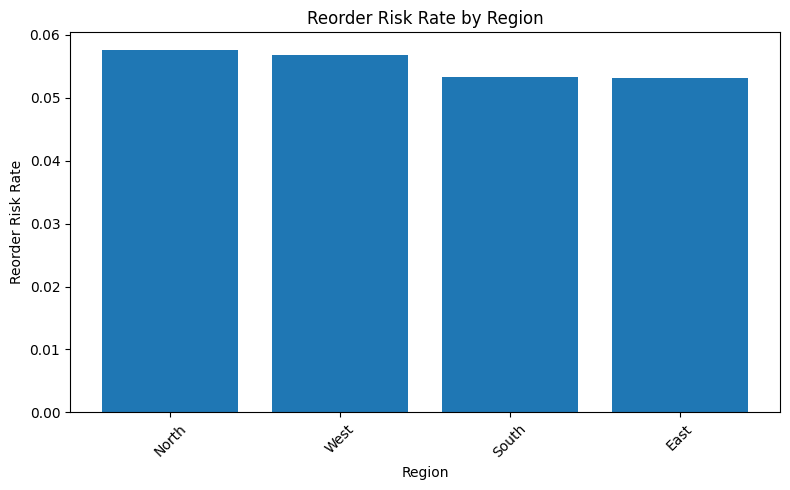

In [62]:
reorder_risk_by_region_plot = reorder_risk_by_region.reset_index()

plt.figure(figsize=(8, 5))
plt.bar(
    reorder_risk_by_region_plot["region"].astype(str),
    reorder_risk_by_region_plot["reorder_risk_rate"]
)

plt.title("Reorder Risk Rate by Region")
plt.xlabel("Region")
plt.ylabel("Reorder Risk Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. Reorder Risk by Warehouse

This view shows which warehouses have the highest share of records at or below the reorder point.

In [63]:
reorder_risk_by_warehouse = (
    df.groupby("warehouse_id")
    .agg(
        records=("reorder_risk_flag", "size"),
        total_units_sold=("units_sold", "sum"),
        avg_inventory_level=("inventory_level", "mean"),
        avg_reorder_point=("reorder_point", "mean"),
        avg_inventory_buffer=("inventory_buffer", "mean"),
        avg_lead_time=("supplier_lead_time_days", "mean"),
        reorder_risk_rate=("reorder_risk_flag", "mean")
    )
    .sort_values("reorder_risk_rate", ascending=False)
)

reorder_risk_by_warehouse.head(10)

,records,total_units_sold,avg_inventory_level,avg_reorder_point,avg_inventory_buffer,avg_lead_time,reorder_risk_rate
warehouse_id,,,,,,,
WH_5,18250,365114,467.116329,299.00,168.116329,6.76,0.055836
WH_3,18250,366110,455.559068,284.96,170.599068,8.22,0.055452
WH_4,18250,365775,477.390301,305.38,172.010301,8.48,0.055233
WH_2,18250,366078,491.489644,318.88,172.609644,8.46,0.055014
WH_1,18250,366902,466.056219,292.12,173.936219,8.00,0.054685


### Warehouse Notes

Reorder risk is also very similar across warehouses. All five warehouses fall between roughly 5.47% and 5.58%.

Because the warehouse-level differences are narrow, warehouse location by itself does not appear to be the main driver of reorder risk in this first pass.

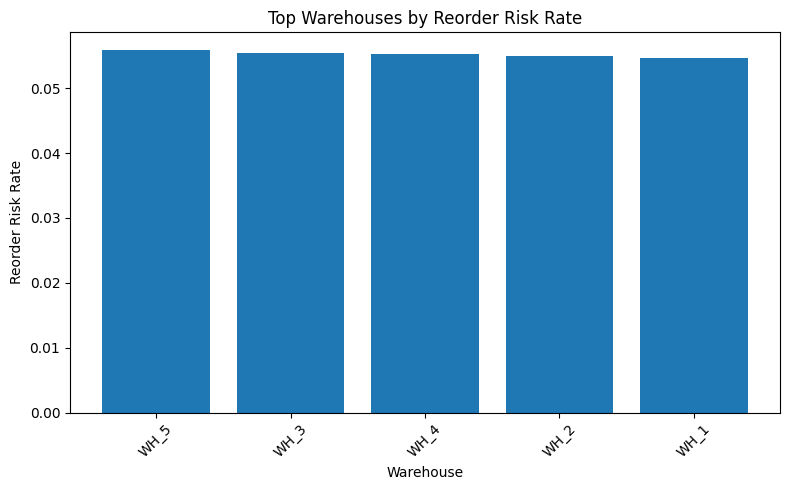

In [64]:
reorder_risk_by_warehouse_plot = reorder_risk_by_warehouse.head(10).reset_index()

plt.figure(figsize=(8, 5))
plt.bar(
    reorder_risk_by_warehouse_plot["warehouse_id"].astype(str),
    reorder_risk_by_warehouse_plot["reorder_risk_rate"]
)

plt.title("Top Warehouses by Reorder Risk Rate")
plt.xlabel("Warehouse")
plt.ylabel("Reorder Risk Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 14. Reorder Risk by Supplier

This view looks at reorder risk by supplier. Average lead time is included because supplier timing can make low inventory more operationally important.

In [65]:
reorder_risk_by_supplier = (
    df.groupby("supplier_id")
    .agg(
        records=("reorder_risk_flag", "size"),
        total_units_sold=("units_sold", "sum"),
        total_skus=("sku_id", "nunique"),
        avg_lead_time=("supplier_lead_time_days", "mean"),
        avg_inventory_buffer=("inventory_buffer", "mean"),
        reorder_risk_rate=("reorder_risk_flag", "mean")
    )
    .sort_values("reorder_risk_rate", ascending=False)
)

reorder_risk_by_supplier.head(10)

,records,total_units_sold,total_skus,avg_lead_time,avg_inventory_buffer,reorder_risk_rate
supplier_id,,,,,,
SUP_6,7300,146684,16,7.900000,171.060685,0.055890
SUP_3,8395,168017,20,8.260870,171.133770,0.055747
SUP_8,10220,205407,22,8.500000,168.413209,0.055675
SUP_2,9490,190999,21,8.423077,171.814858,0.055532
SUP_4,9125,183147,22,8.640000,172.037699,0.055342
SUP_9,5840,117259,16,8.187500,172.340411,0.055308
SUP_10,9855,197242,21,7.407407,171.029528,0.055302
SUP_7,12410,248830,29,7.558824,171.905802,0.054875
SUP_1,10220,204249,23,8.107143,171.404207,0.054795


### Supplier Notes

Supplier-level reorder risk is tightly clustered. The highest supplier reorder risk rate is 5.59%, while the lowest is 5.42%.

This suggests that supplier identity alone does not separate high-risk from low-risk records very strongly in the initial review. Supplier lead time may still matter, but it likely needs to be considered together with inventory buffer, demand, promotions, and time period.

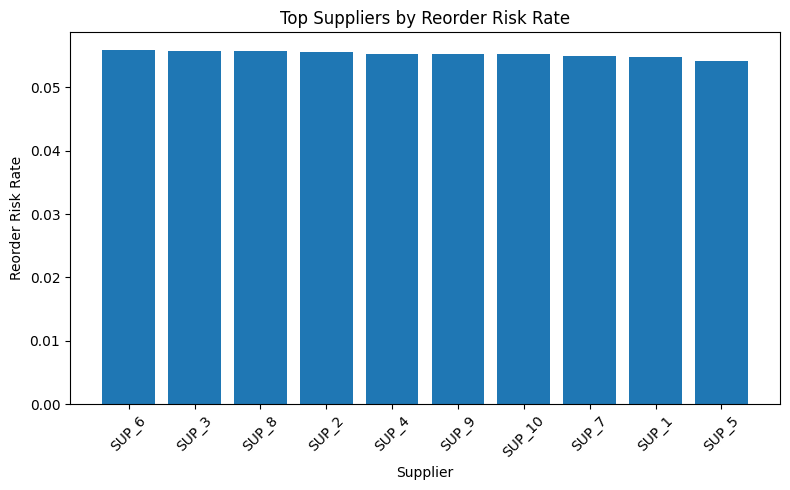

In [66]:
reorder_risk_by_supplier_plot = reorder_risk_by_supplier.head(10).reset_index()

plt.figure(figsize=(8, 5))
plt.bar(
    reorder_risk_by_supplier_plot["supplier_id"].astype(str),
    reorder_risk_by_supplier_plot["reorder_risk_rate"]
)

plt.title("Top Suppliers by Reorder Risk Rate")
plt.xlabel("Supplier")
plt.ylabel("Reorder Risk Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 15. Inventory Buffer Review

Inventory buffer shows how far each record sits above or below the reorder point. I grouped the buffer values to make the pattern easier to read.

In [67]:
df["inventory_buffer"].describe()

,inventory_buffer
count,91250.000000
mean,171.454312
std,122.626009
min,-49.000000
25%,71.000000
50%,160.000000
75%,258.000000
max,744.000000


In [68]:
df["inventory_buffer_group"] = pd.cut(
    df["inventory_buffer"],
    bins=[-np.inf, 0, 25, 75, np.inf],
    labels=[
        "At or below reorder point",
        "Low buffer",
        "Moderate buffer",
        "High buffer"
    ]
)

df["inventory_buffer_group"].value_counts(dropna=False)

,count
inventory_buffer_group,
High buffer,67176
Moderate buffer,12719
Low buffer,6314
At or below reorder point,5041


In [69]:
buffer_summary = (
    df.groupby("inventory_buffer_group", observed=False)
    .agg(
        records=("reorder_risk_flag", "size"),
        avg_inventory_buffer=("inventory_buffer", "mean"),
        avg_units_sold=("units_sold", "mean"),
        avg_lead_time=("supplier_lead_time_days", "mean"),
        reorder_risk_rate=("reorder_risk_flag", "mean")
    )
)

buffer_summary

,records,avg_inventory_buffer,avg_units_sold,avg_lead_time,reorder_risk_rate
inventory_buffer_group,,,,,
At or below reorder point,5041,-11.683595,24.318786,7.985122,1.0
Low buffer,6314,12.972917,19.977035,7.967849,0.0
Moderate buffer,12719,50.571507,20.078780,7.981131,0.0
High buffer,67176,222.981020,19.737272,7.985977,0.0


### Inventory Buffer Notes

The inventory buffer groups behave as expected. Records at or below the reorder point have a reorder risk rate of 100% because that group directly defines the reorder risk flag.

The more useful finding is the distribution of records. Most records fall into the high buffer group, while 5,041 records sit at or below the reorder point. This confirms that reorder risk is not widespread across the full dataset, but there is a clear subset of records that should be isolated for closer review.

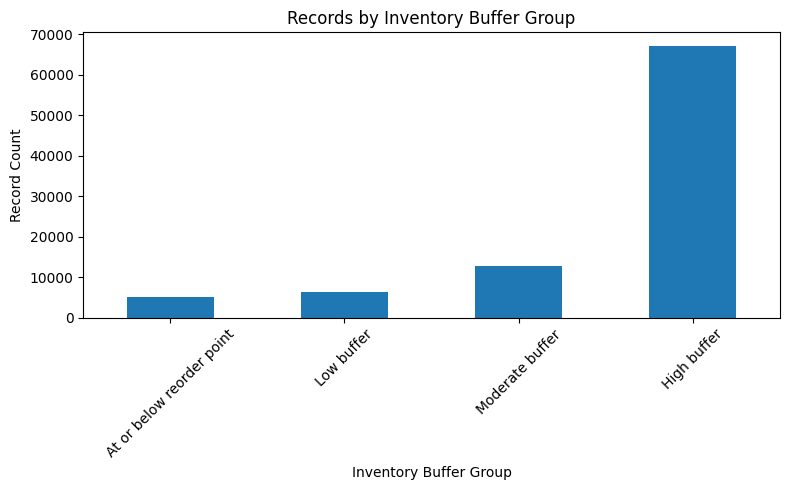

In [70]:
buffer_summary["records"].plot(kind="bar", figsize=(8, 5))

plt.title("Records by Inventory Buffer Group")
plt.xlabel("Inventory Buffer Group")
plt.ylabel("Record Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 16. Forecast Error Review

Forecast error compares actual units sold with forecasted demand.

Positive forecast error means actual sales were higher than forecast. Negative forecast error means actual sales were lower than forecast.

In [71]:
df[["units_sold", "demand_forecast", "forecast_error", "absolute_forecast_error"]].describe()

,units_sold,demand_forecast,forecast_error,absolute_forecast_error
count,91250.000000,91250.000000,91250.000000,91250.000000
mean,20.054564,20.082033,-0.027469,2.379817
std,9.068602,9.503955,2.987263,1.805797
min,0.000000,0.000000,-14.080000,0.000000
25%,13.000000,12.950000,-2.030000,0.950000
50%,20.000000,19.950000,-0.010000,2.000000
75%,27.000000,26.930000,1.990000,3.440000
max,59.000000,61.420000,13.000000,14.080000


In [72]:
df["forecast_bias"] = np.where(
    df["forecast_error"] > 0,
    "Under-forecasted",
    np.where(df["forecast_error"] < 0, "Over-forecasted", "Neutral")
)

df["forecast_bias"].value_counts()

,count
forecast_bias,
Over-forecasted,45649
Under-forecasted,45160
Neutral,441


In [73]:
forecast_bias_summary = (
    df.groupby("forecast_bias")
    .agg(
        records=("reorder_risk_flag", "size"),
        avg_units_sold=("units_sold", "mean"),
        avg_demand_forecast=("demand_forecast", "mean"),
        avg_forecast_error=("forecast_error", "mean"),
        avg_absolute_forecast_error=("absolute_forecast_error", "mean"),
        avg_inventory_buffer=("inventory_buffer", "mean"),
        reorder_risk_rate=("reorder_risk_flag", "mean")
    )
    .sort_values("reorder_risk_rate", ascending=False)
)

forecast_bias_summary

,records,avg_units_sold,avg_demand_forecast,avg_forecast_error,avg_absolute_forecast_error,avg_inventory_buffer,reorder_risk_rate
forecast_bias,,,,,,,
Under-forecasted,45160,20.242936,17.866367,2.376569,2.376569,170.971391,0.056067
Over-forecasted,45649,19.999474,22.405494,-2.406020,2.406020,171.855397,0.054744
Neutral,441,6.467120,6.467120,0.000000,0.000000,179.390023,0.022676


### Forecast Bias Notes

Forecast bias is balanced overall. Under-forecasted and over-forecasted records occur at similar volumes, and the average forecast error is close to zero at the dataset level.

Reorder risk is slightly higher among under-forecasted records than over-forecasted records, but the difference is small. Forecast error may still be useful in the later modeling phase, but it does not appear to dominate reorder risk by itself in this first review.

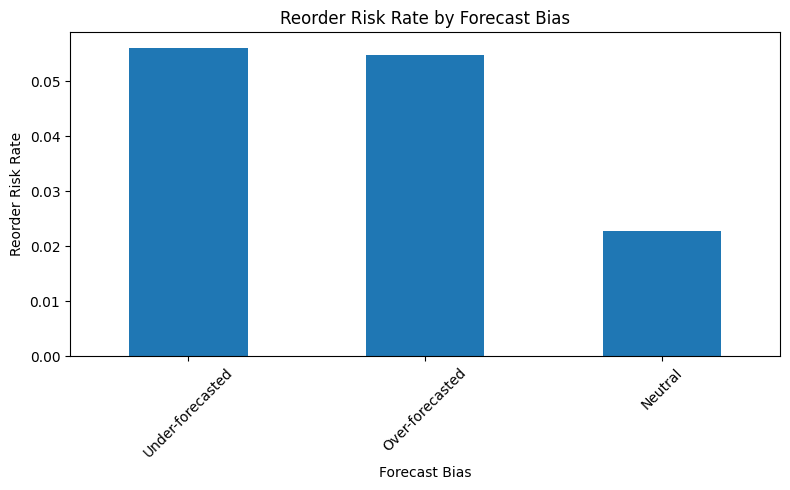

In [74]:
forecast_bias_summary["reorder_risk_rate"].plot(kind="bar", figsize=(8, 5))

plt.title("Reorder Risk Rate by Forecast Bias")
plt.xlabel("Forecast Bias")
plt.ylabel("Reorder Risk Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 17. Promotion Review

Promotions can raise demand pressure. This summary compares promoted and non-promoted records across demand, forecast error, inventory buffer, and reorder risk.

In [75]:
promotion_summary = (
    df.groupby("promotion_flag")
    .agg(
        records=("reorder_risk_flag", "size"),
        avg_units_sold=("units_sold", "mean"),
        avg_demand_forecast=("demand_forecast", "mean"),
        avg_forecast_error=("forecast_error", "mean"),
        avg_absolute_forecast_error=("absolute_forecast_error", "mean"),
        avg_inventory_buffer=("inventory_buffer", "mean"),
        reorder_risk_rate=("reorder_risk_flag", "mean")
    )
)

promotion_summary

,records,avg_units_sold,avg_demand_forecast,avg_forecast_error,avg_absolute_forecast_error,avg_inventory_buffer,reorder_risk_rate
promotion_flag,,,,,,,
0,81980,19.504977,19.534176,-0.029199,2.382167,172.015736,0.053354
1,9270,24.914887,24.927057,-0.012170,2.359033,166.489320,0.071953


### Promotion Notes

Promotion status shows a clearer early signal than region, warehouse, or supplier. Promoted records have a reorder risk rate of 7.20%, compared with 5.34% for non-promoted records.

Promoted records also have higher average units sold and a lower average inventory buffer.

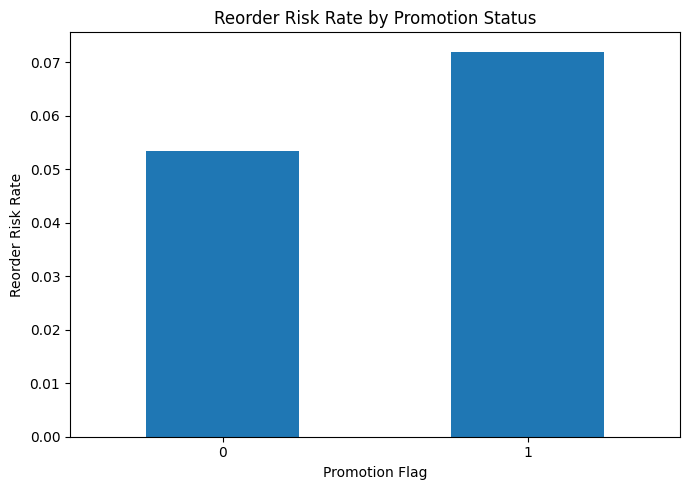

In [76]:
promotion_summary["reorder_risk_rate"].plot(kind="bar", figsize=(7, 5))

plt.title("Reorder Risk Rate by Promotion Status")
plt.xlabel("Promotion Flag")
plt.ylabel("Reorder Risk Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 18. Monthly Trend Review

This view checks whether units sold, reorder risk, inventory buffer, or forecast error shift over time.

In [77]:
monthly_summary = (
    df.groupby("month_year")
    .agg(
        records=("reorder_risk_flag", "size"),
        total_units_sold=("units_sold", "sum"),
        avg_inventory_buffer=("inventory_buffer", "mean"),
        reorder_risk_rate=("reorder_risk_flag", "mean"),
        avg_absolute_forecast_error=("absolute_forecast_error", "mean")
    )
    .reset_index()
)

monthly_summary.head()

,month_year,records,total_units_sold,avg_inventory_buffer,reorder_risk_rate,avg_absolute_forecast_error
0,2024-01,7750,176681,227.401935,0.041935,2.399005
1,2024-02,7250,197188,159.880000,0.078069,2.416770
2,2024-03,7750,231596,159.000387,0.083355,2.392874
3,2024-04,7500,223793,154.349600,0.084667,2.375808
4,2024-05,7750,210841,159.013161,0.077935,2.402512


### Monthly Notes

Monthly reorder risk varies more than the region, warehouse, and supplier summaries. January has a lower reorder risk rate and a much higher average inventory buffer, while February through May show higher reorder risk and lower average buffers.

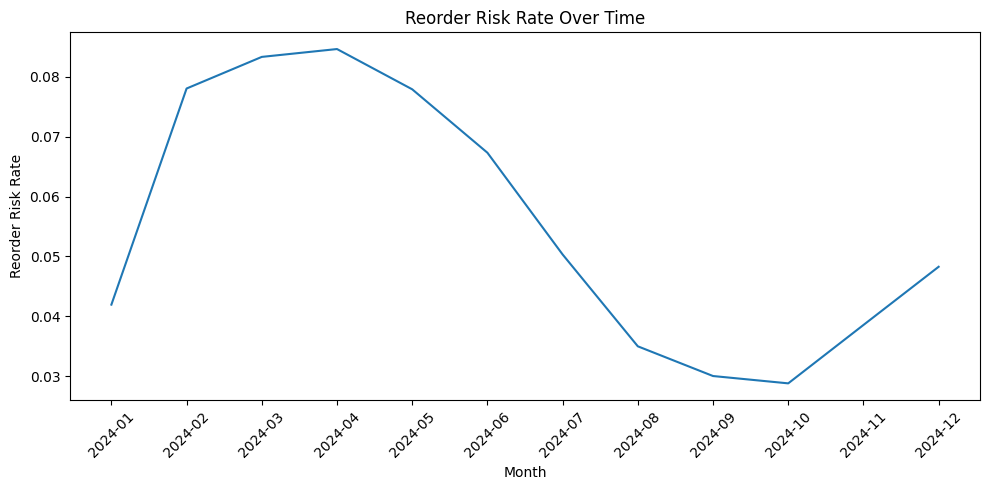

In [78]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_summary["month_year"], monthly_summary["reorder_risk_rate"])

plt.title("Reorder Risk Rate Over Time")
plt.xlabel("Month")
plt.ylabel("Reorder Risk Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 19. Save Cleaned Dataset

In [79]:
df.to_csv("supply_chain_inventory_cleaned.csv", index=False)

In [80]:
from google.colab import files

files.download("supply_chain_inventory_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notebook Summary

This notebook cleaned the supply chain inventory dataset and created the first set of planning fields for the project.

The basic data quality review was clean: the dataset has 91,250 records, no missing values, and no duplicate rows. The main adjustment was analytical rather than technical. Although the dataset includes a `stockout_flag` field, every record is coded as non-stockout, so the project should not force a stockout prediction workflow.

I used reorder risk as the first practical inventory planning signal. Reorder risk identifies records where inventory is at or below the reorder point. In this dataset, 5.52% of records fall into that category.

The first review shows that reorder risk does not differ much by region, warehouse, or supplier. Promotion status shows a clearer signal, with promoted records carrying a higher reorder risk rate than non-promoted records. Monthly patterns also appear more meaningful than broad operating segments.

The next phase should focus on SKU-level patterns, promotion effects, monthly variation, and a simple risk segmentation approach rather than stockout prediction.